In [10]:
import json

In [11]:
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ["#89c8e8","#caa2f4","#1f78b4","#6a3d9a","#8acc72", "#ebd57c", "#ed4437", "#fc9a9a"]
tag = ['Zip', 'Random', 'Cluster', 'Perplexity', 'Deita', 'SuperFiltering']

In [12]:
# import zlib
# import json
# def get_compression_ratio(input_data):
#     data_str = str(input_data).encode('utf-8')
#     compressed_data = zlib.compress(data_str, level=9)
#     compressed_ratio = len(data_str) / len(compressed_data)
#     return compressed_ratio



# data_file = json.load(open('/zhdd/home/mjyin/Projects/axolotl/data/token_llama3_re/token_llama3_re_IFD_truncated.json', 'r'))

# get_compression_ratio([_['conversations'] for _ in data_file])

In [13]:

mt_bench = [7.28, 7.16, 7.18, 7.09, 7.11, 6.59]
compression_ratio = [2.45, 3.29, 3.296, 3.30, 3.51, 4.95]
# converge_loss = [0.62, 0.6623619047619048, 0.5751619047619047, 0.5561714285714286, 0.5550545454545454, 0.548195238095238, 0.2805090909090909, 0.24121904761904767]
first_epoch_loss = [1.04, 0.8987, 0.9064, 0.8784, 0.7922, 0.6298]

import matplotlib.pyplot as plt
import math
# 数据点
x = compression_ratio  # x轴上的数据点
y = mt_bench  # y轴上的数据点
y2 = first_epoch_loss


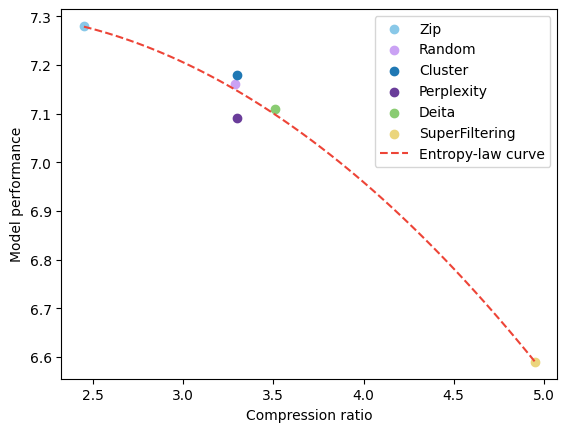

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 假设我们有一组数据点
x = compression_ratio
y = mt_bench

# 使用polyfit进行多项式拟合，这里选择3阶多项式


# Perform polynomial fitting using polyfit, here we choose a cubic polynomial
coefficients = np.polyfit(x, y, 2)

# Create a polynomial function based on the coefficients
p = np.poly1d(coefficients)

# Create an array of x values for plotting the curve
x_fit = np.linspace(min(x), max(x), 100)

# Calculate the y values of the fitting curve using the polynomial function
y_fit = p(x_fit)

# Plot the original data points with different colors for each point
for xi, yi, color, point_tag in zip(x, y, colors, tag):
    plt.scatter(xi, yi, color=color, label=point_tag)
    # plt.text(xi, yi, f'({xi},{yi})', fontsize=9, verticalalignment='bottom')

# Plot the fitting curve
plt.plot(x_fit, y_fit, label='Entropy-law curve', color=colors[len(tag)], linestyle='--')

# Add legend
plt.legend()

# Add title and axis labels
plt.ylabel('Model performance')
plt.xlabel('Compression ratio')

# Display the plot
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/entropy-law/llama3_compress.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()

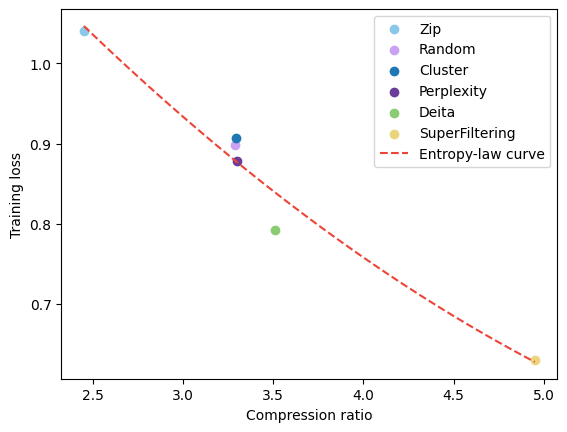

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 假设我们有一组数据点
x = compression_ratio
y = first_epoch_loss

# 使用polyfit进行多项式拟合，这里选择3阶多项式


# Perform polynomial fitting using polyfit, here we choose a cubic polynomial
coefficients = np.polyfit(x, y, 2)

# Create a polynomial function based on the coefficients
p = np.poly1d(coefficients)

# Create an array of x values for plotting the curve
x_fit = np.linspace(min(x), max(x), 100)

# Calculate the y values of the fitting curve using the polynomial function
y_fit = p(x_fit)

# Plot the original data points with different colors for each point
for xi, yi, color, point_tag in zip(x, y, colors, tag):
    plt.scatter(xi, yi, color=color, label=point_tag)
    # plt.text(xi, yi, f'({xi},{yi})', fontsize=9, verticalalignment='bottom')

# Plot the fitting curve
plt.plot(x_fit, y_fit, label='Entropy-law curve', color=colors[len(tag)], linestyle='--')

# Add legend
plt.legend()

# Add title and axis labels
plt.xlabel('Compression ratio')
plt.ylabel('Training loss')

# Display the plot
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/entropy-law/entropy_llama3_law_RL.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()

In [16]:
import numpy as np
from scipy.stats import pearsonr
# 假设有两个列表
list1 = np.array(mt_bench)
list3 = np.array(first_epoch_loss)

# 将列表转换为NumPy数组
array1 = np.array(list1)
array3 = np.array(list3)

# 计算相关系数矩阵
corr_matrix_13, _ = pearsonr(array1, array3)
print("相关系数:", corr_matrix_13)

相关系数: 0.9255316584431079


In [17]:

# # llama3
# import matplotlib.pyplot as plt
# import math
# # 数据点

# plt.figure(figsize=(5, 5))
# # 创建折线图
# plt.plot(x, y2, label=f"first_epoch_loss {corr_matrix_13:.2f}")  # 'o'表示在每个数据点上画一个圆形标记
# for i, label in enumerate(tag):
#     plt.text(x[i], y2[i], label, fontsize=12, ha='center', va='bottom')
# # 添加标题和标签
# plt.title('Simple Line Chart')
# plt.xlabel('Compression ratio')
# plt.ylabel('Batch Loss')
# plt.legend()

# # 显示网格（可选）
# plt.grid(True)

# # 显示图表
# plt.show()

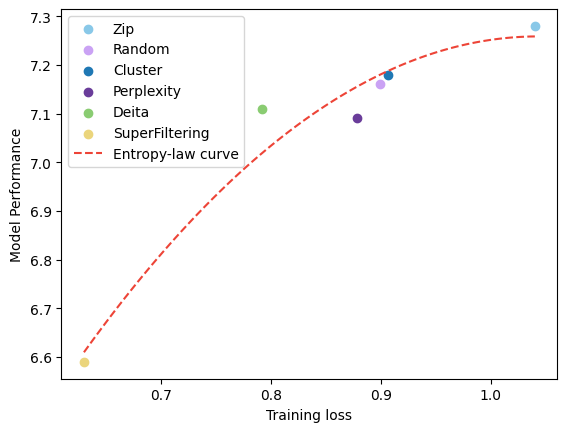

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 假设我们有一组数据点
x = first_epoch_loss
y = mt_bench

# Perform polynomial fitting using polyfit, here we choose a cubic polynomial
coefficients = np.polyfit(x, y, 2, rcond=2e-16)

# Create a polynomial function based on the coefficients
p = np.poly1d(coefficients)

# Create an array of x values for plotting the curve
x_fit = np.linspace(min(x), max(x), 100)

# Calculate the y values of the fitting curve using the polynomial function
y_fit = p(x_fit)

# Plot the original data points with different colors for each point
for xi, yi, color, point_tag in zip(x, y, colors, tag):
    plt.scatter(xi, yi, color=color, label=point_tag)
    # plt.text(xi, yi, f'({xi},{yi})', fontsize=9, verticalalignment='bottom')

# Plot the fitting curve
plt.plot(x_fit, y_fit, label='Entropy-law curve', color=colors[len(tag)], linestyle='--')

# Add legend
plt.legend()

# Add title and axis labels
plt.xlabel('Training loss')
plt.ylabel('Model Performance')

# Display the plot
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/entropy-law/llama3_loss.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()